# IMDb Movie Recommendation System

## 1. Exploratory Data Analysis

This notebook performs Exploratory Data Analysis (EDA) on the IMDb 2024 movie dataset used for building a storyline-based movie recommendation system.

The dataset contains movie titles and their corresponding storylines. The purpose of this analysis is to understand the structure, completeness, text characteristics, and potential issues in the dataset before applying Natural Language Processing (NLP) techniques.

### Objectives

- Understand the structure of the dataset.
- Inspect data types and dataset dimensions.
- Check for missing and duplicate records.
- Analyze movie title characteristics.
- Analyze storyline length and distribution.
- Identify potential text-quality issues.
- Examine common words and vocabulary patterns.
- Identify potential outliers in storyline length.
- Derive insights that will guide the NLP preprocessing stage.

In [38]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Locate project root dynamically
current_dir = Path.cwd()

project_root = next(
    (
        path
        for path in [current_dir, *current_dir.parents]
        if (path / "src" / "config.py").exists()
    ),
    None
)

if project_root is None:
    raise FileNotFoundError(
        "Project root could not be located. "
        "Make sure the notebook is inside the project."
    )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [39]:
from src.config import RAW_DATA_PATH

print("Project root:", project_root)
print("Dataset path:", RAW_DATA_PATH)

Project root: d:\Projects\Python Projects\Python Mini Projects\IMDB_Movie_Recommendation_System
Dataset path: D:\Projects\Python Projects\Python Mini Projects\IMDB_Movie_Recommendation_System\data\IMDBRecSys.csv


In [40]:
df = pd.read_csv(RAW_DATA_PATH)

df.head()

,Movie_Title,Storyline
0,1. The Fall Guy,"A stuntman, fresh off an almost career-ending ..."
1,2. The Substance,A fading celebrity takes a black-market drug: ...
2,3. The Life of Chuck,"A life-affirming, genre-bending story about th..."
3,4. Abigail,After a group of criminals kidnap the ballerin...
4,5. The Ministry of Ungentlemanly Warfare,The British military recruits a small group of...


## 2. Dataset Overview

The first step is to understand the size, structure, and data types of the dataset.

In [41]:
print(f"Number of rows    : {df.shape[0]:,}")
print(f"Number of columns : {df.shape[1]}")

Number of rows    : 6,021
Number of columns : 2


In [42]:
print("Columns:")
for column in df.columns:
    print(f"- {column}")

Columns:
- Movie_Title
- Storyline


In [43]:
df.dtypes

Movie_Title    object
Storyline      object
dtype: object

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6021 entries, 0 to 6020
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Movie_Title  6021 non-null   object
 1   Storyline    6021 non-null   object
dtypes: object(2)
memory usage: 94.2+ KB


In [45]:
df.describe(include="object").T

,count,unique,top,freq
Movie_Title,6021,6021,1. The Fall Guy,1
Storyline,6021,6019,"Tanit, Valeria and Shaila are three women from...",2


## 3. Data Quality Analysis

Before applying NLP techniques, the dataset must be checked for:

- Missing values
- Duplicate rows
- Duplicate movie titles
- Empty text fields
- Invalid or placeholder values

In [46]:
missing_values = df.isnull().sum()

missing_values

Movie_Title    0
Storyline      0
dtype: int64

In [47]:
print(
    f"Total missing values: {df.isnull().sum().sum()}"
)

Total missing values: 0


In [48]:
empty_titles = df["Movie_Title"].astype(str).str.strip().eq("").sum()
empty_storylines = df["Storyline"].astype(str).str.strip().eq("").sum()

print("Empty movie titles :", empty_titles)
print("Empty storylines   :", empty_storylines)

Empty movie titles : 0
Empty storylines   : 0


In [49]:
duplicate_rows = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_rows}")

Duplicate rows: 0


In [50]:
duplicate_titles = df["Movie_Title"].duplicated().sum()

print(f"Duplicate movie titles: {duplicate_titles}")

Duplicate movie titles: 0


### Data Quality Findings

The dataset contains complete movie title and storyline records. No missing values, empty fields, duplicate rows, or duplicate movie titles were identified during the initial inspection.

Therefore, no record-level deletion is required at the EDA stage. Text normalization and preprocessing will be handled separately in the NLP preprocessing notebook.

In [51]:
df["Movie_Title"].head(20).to_list()

['1. The Fall Guy',
 '2. The Substance',
 '3. The Life of Chuck',
 '4. Abigail',
 '5. The Ministry of Ungentlemanly Warfare',
 '6. Relay',
 '7. Dune: Part Two',
 '8. Anora',
 '9. Jab Khuli Kitaab',
 "10. I'm Still Here",
 '11. Eden',
 '12. Ghostbusters: Frozen Empire',
 '13. Blink Twice',
 '14. Deadpool & Wolverine',
 '15. We Bury the Dead',
 '16. Babygirl',
 '17. Nosferatu',
 '18. The Wild Robot',
 '19. Kinds of Kindness',
 '20. Wicked']

In [52]:
numbered_titles = df["Movie_Title"].str.match(
    r"^\s*\d+\.\s*"
).sum()

print(f"Titles containing a leading number: {numbered_titles:,}")

Titles containing a leading number: 6,021


In [53]:
df["title_length"] = df["Movie_Title"].str.len()

In [54]:
df["title_length"].describe()

count    6021.000000
mean       21.694901
std         9.523450
min         6.000000
25%        15.000000
50%        20.000000
75%        26.000000
max       105.000000
Name: title_length, dtype: float64

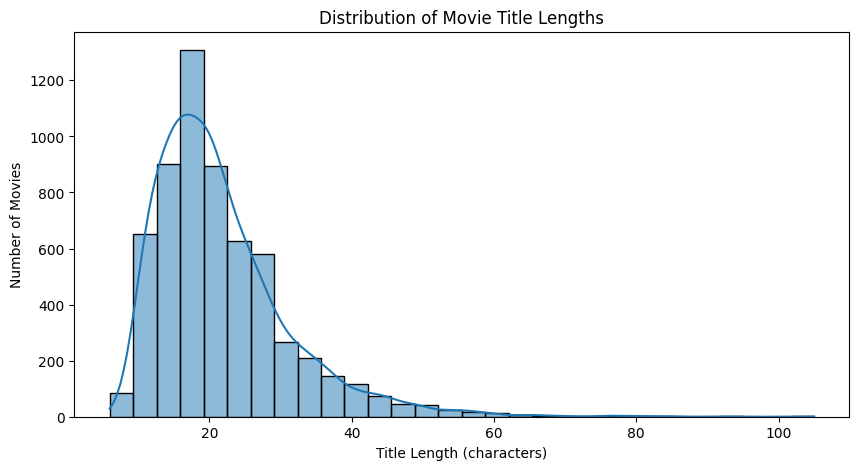

In [55]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["title_length"],
    bins=30,
    kde=True
)

plt.title("Distribution of Movie Title Lengths")
plt.xlabel("Title Length (characters)")
plt.ylabel("Number of Movies")

plt.show()

In [56]:
df["storyline_length"] = df["Storyline"].str.len()

In [57]:
df["storyline_length"].describe()

count    6021.000000
mean      197.624315
std       119.455433
min        25.000000
25%       145.000000
50%       187.000000
75%       225.000000
max      2668.000000
Name: storyline_length, dtype: float64

In [58]:
df["word_count"] = (
    df["Storyline"]
    .str.split()
    .str.len()
)

In [59]:
df["word_count"].describe()

count    6021.000000
mean       32.730277
std        20.116917
min         4.000000
25%        24.000000
50%        30.000000
75%        37.000000
max       463.000000
Name: word_count, dtype: float64

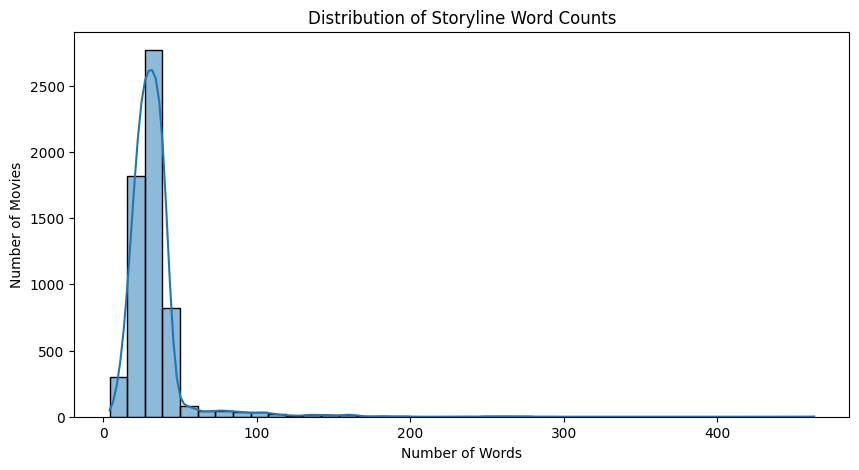

In [60]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["word_count"],
    bins=40,
    kde=True
)

plt.title("Distribution of Storyline Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Number of Movies")

plt.show()

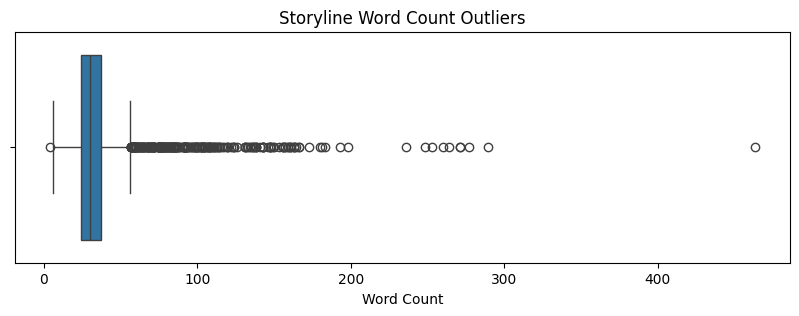

In [61]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    x=df["word_count"]
)

plt.title("Storyline Word Count Outliers")
plt.xlabel("Word Count")

plt.show()

In [62]:
short_storylines = df[df["word_count"] < 10][
    ["Movie_Title", "Storyline", "word_count"]
]

short_storylines

,Movie_Title,Storyline,word_count
281,282. Waves,A compromising record can change history.,6
462,463. Buy Now! The Shopping Conspiracy,Follows the life of legendary composer John Wi...,8
1019,1020. Saba,Modern version of Orpheus and Eurydice.,6
1048,1049. The Grinch that Stole Bitches,A young woman has to run for her life.,9
1144,1145. Sikandar Ka Muqaddar,It honors the heroes of the 100th Bomb Group.,9
1394,1395. Secret Sessions,"The life story of legendary folk singer, Neset...",9
1490,1491. Munkar,Life of Dzej Ramadanovski the popular Serbian ...,9
1626,1627. Yudhra,Psychedelic technosatire feature about growing...,8
1645,1646. Agak Laen,A World War 1 Romantic Ghost Story,7
2147,2148. Over the Red River,A comedic thriller about virtual reality-gone-...,6


In [63]:
long_storylines = df[df["word_count"] > 100][
    ["Movie_Title", "Storyline", "word_count"]
].sort_values(
    "word_count",
    ascending=False
)

long_storylines.head(20)

,Movie_Title,Storyline,word_count
4589,4590. Sureshinteyum Sumalathayudeyum Hridayaha...,Story of A Girl Nandini who dreamed of becomin...,463
5969,5970. Troll Storm,Stavros is a somewhat unsuccessful filmmaker w...,289
5316,5317. Hotel Bitcoin,A girl named Anya and her boyfriend Yurko come...,277
4385,4386. Bloodline,In the Chris Marker exhibition at the Cinémath...,271
4570,4571. What Ravens Do,The Sweet Life: A Hockey World Champion and lo...,271
3482,3483. The Great Tram Robbery,In the heart of the 17th-century Uzbek Bukhara...,264
5619,5620. Kargil 1999- The Untold Story of the Ind...,A blazingly colorful and exuberantly transgres...,260
4793,4794. Holiday Hold-Up,Between Borders presents three stories set in ...,253
5345,5346. The Yorkie Werewolf,"Leandre Sanders was born in Venice Beach, LA, ...",248
5653,5654. Csendes éj,"In 2019, winemaker Hugo D'Acosta and chef Beni...",236


In [64]:
percentiles = df["word_count"].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

percentiles

0.25     24.0
0.50     30.0
0.75     37.0
0.90     42.0
0.95     51.0
0.99    123.8
Name: word_count, dtype: float64

In [65]:
from collections import Counter

all_words = " ".join(
    df["Storyline"].astype(str)
).lower().split()

word_frequency = Counter(all_words)

word_frequency.most_common(30)

[('a', 9849),
 ('the', 8838),
 ('to', 5877),
 ('and', 5753),
 ('of', 5284),
 ('in', 3792),
 ('his', 2625),
 ('her', 2466),
 ('with', 1961),
 ('is', 1873),
 ('their', 1692),
 ('an', 1657),
 ('for', 1529),
 ('on', 1362),
 ('as', 1194),
 ('he', 1119),
 ('from', 1074),
 ('by', 1072),
 ('that', 1064),
 ('who', 1026),
 ('when', 976),
 ('they', 951),
 ('she', 938),
 ('after', 816),
 ('into', 688),
 ('but', 677),
 ('at', 629),
 ('life', 587),
 ('young', 525),
 ('are', 521)]

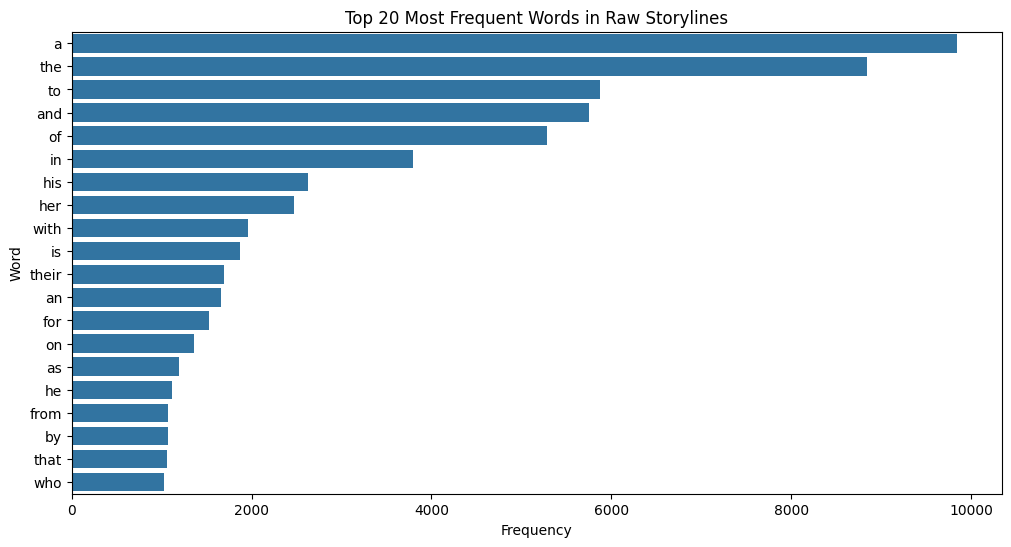

In [66]:
common_words = pd.DataFrame(
    word_frequency.most_common(20),
    columns=["word", "frequency"]
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=common_words,
    x="frequency",
    y="word"
)

plt.title("Top 20 Most Frequent Words in Raw Storylines")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

In [67]:
import re

special_character_count = df["Storyline"].apply(
    lambda text: len(re.findall(r"[^a-zA-Z0-9\s]", str(text)))
)

special_character_count.describe()

count    6021.000000
mean        4.786082
std         3.878822
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        63.000000
Name: Storyline, dtype: float64

In [68]:
df.loc[
    special_character_count.nlargest(10).index,
    ["Movie_Title", "Storyline"]
]

,Movie_Title,Storyline
4589,4590. Sureshinteyum Sumalathayudeyum Hridayaha...,Story of A Girl Nandini who dreamed of becomin...
4765,4766. Bauk,"Self-styled ""revolutionary"" Chris (T. Ryder Sm..."
4385,4386. Bloodline,In the Chris Marker exhibition at the Cinémath...
5619,5620. Kargil 1999- The Untold Story of the Ind...,A blazingly colorful and exuberantly transgres...
4570,4571. What Ravens Do,The Sweet Life: A Hockey World Champion and lo...
3657,3658. Keep Rolling,Music driven horror-comedy. A voodoo deity tra...
5402,5403. The Million Dollar Bet,A group of entitled nepo babies go to Sagada f...
3590,3591. Yasam Koçu,"One island, 40 inhabitants, two scammers. On a..."
4793,4794. Holiday Hold-Up,Between Borders presents three stories set in ...
5969,5970. Troll Storm,Stavros is a somewhat unsuccessful filmmaker w...


In [69]:
df.nlargest(
    10,
    "word_count"
)[
    ["Movie_Title", "word_count", "Storyline"]
]

,Movie_Title,word_count,Storyline
4589,4590. Sureshinteyum Sumalathayudeyum Hridayaha...,463,Story of A Girl Nandini who dreamed of becomin...
5969,5970. Troll Storm,289,Stavros is a somewhat unsuccessful filmmaker w...
5316,5317. Hotel Bitcoin,277,A girl named Anya and her boyfriend Yurko come...
4385,4386. Bloodline,271,In the Chris Marker exhibition at the Cinémath...
4570,4571. What Ravens Do,271,The Sweet Life: A Hockey World Champion and lo...
3482,3483. The Great Tram Robbery,264,In the heart of the 17th-century Uzbek Bukhara...
5619,5620. Kargil 1999- The Untold Story of the Ind...,260,A blazingly colorful and exuberantly transgres...
4793,4794. Holiday Hold-Up,253,Between Borders presents three stories set in ...
5345,5346. The Yorkie Werewolf,248,"Leandre Sanders was born in Venice Beach, LA, ..."
5653,5654. Csendes éj,236,"In 2019, winemaker Hugo D'Acosta and chef Beni..."


In [70]:
df.nsmallest(
    10,
    "word_count"
)[
    ["Movie_Title", "word_count", "Storyline"]
]

,Movie_Title,word_count,Storyline
3247,3248. Stupid Games,4,An internet romance scam.
281,282. Waves,6,A compromising record can change history.
1019,1020. Saba,6,Modern version of Orpheus and Eurydice.
2147,2148. Over the Red River,6,A comedic thriller about virtual reality-gone-...
5069,5070. Karaoké,6,"This is a ""Bülent DURGUN"" MOVIE"
5176,5177. Astrid's Saints,6,Revolves around the Punjabi wedding culture.
1645,1646. Agak Laen,7,A World War 1 Romantic Ghost Story
2471,2472. Antropophagus Legacy,7,Based on the book by Domenico Starnone
2854,2855. Malês,7,One family's journey through life and death.
5954,5955. Half-Life of Memory: America's Forgotten...,7,Follows Walt Disney journey to building Disney...


In [71]:
correlation = df[
    ["title_length", "word_count"]
].corr()

correlation

,title_length,word_count
title_length,1.000000,0.045619
word_count,0.045619,1.000000


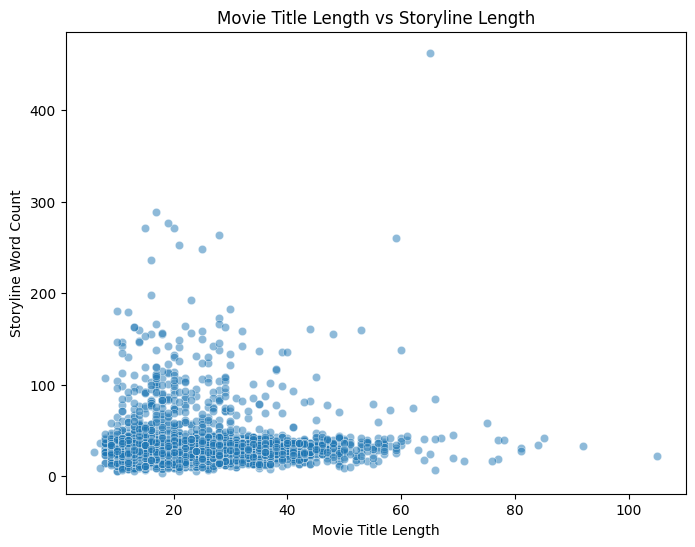

In [72]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="title_length",
    y="word_count",
    alpha=0.5
)

plt.title("Movie Title Length vs Storyline Length")
plt.xlabel("Movie Title Length")
plt.ylabel("Storyline Word Count")

plt.show()

In [73]:
eda_summary = pd.DataFrame({
    "Metric": [
        "Number of Movies",
        "Unique Movie Titles",
        "Missing Values",
        "Duplicate Rows",
        "Duplicate Titles",
        "Average Storyline Words",
        "Median Storyline Words",
        "Shortest Storyline",
        "Longest Storyline"
    ],
    "Value": [
        len(df),
        df["Movie_Title"].nunique(),
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        df["Movie_Title"].duplicated().sum(),
        round(df["word_count"].mean(), 2),
        round(df["word_count"].median(), 2),
        df["word_count"].min(),
        df["word_count"].max()
    ]
})

eda_summary

,Metric,Value
0,Number of Movies,6021.00
1,Unique Movie Titles,6021.00
2,Missing Values,0.00
3,Duplicate Rows,0.00
4,Duplicate Titles,0.00
5,Average Storyline Words,32.73
6,Median Storyline Words,30.00
7,Shortest Storyline,4.00
8,Longest Storyline,463.00


## 4. EDA Findings

The exploratory analysis produced the following observations:

1. The dataset contains 6,021 movie records with two primary text attributes: movie title and storyline.

2. The dataset does not contain missing values or duplicate records.

3. Movie titles are unique within the dataset.

4. Movie titles contain a leading numerical index, which is not part of the actual movie title and should be removed during preprocessing.

5. Storylines vary considerably in length. Most storylines are relatively short, while a smaller number contain substantially longer descriptions.

6. A small number of storylines contain fewer than 10 words and should be inspected rather than automatically removed.

7. Raw storyline text contains common English stop words and punctuation. These elements are potential candidates for removal during NLP preprocessing.

8. The variation in storyline content and length makes TF-IDF an appropriate candidate for representing the textual information used by the recommendation system.

9. No record-level cleaning such as duplicate removal or missing-value imputation is required based on the initial dataset quality checks.

## 5. Conclusion

The IMDb movie dataset is structurally simple and contains complete movie title and storyline information.

The EDA confirms that the main preprocessing requirement is text normalization rather than extensive tabular data cleaning.

The next stage will focus on Natural Language Processing, including:

- Removing title numbering.
- Converting text to a consistent format.
- Removing punctuation and unnecessary characters.
- Removing stop words.
- Tokenizing the storyline text.
- Preparing cleaned storylines for TF-IDF vectorization.

The cleaned text will then be used to build the storyline-based movie recommendation system.